# Case Study: Actinoform Clouds

In [1]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

## Download Data 

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="oci")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [4]:
results = earthaccess.search_data(
    short_name= "PACE_OCI_L2_CLOUD", 
    # temporal= ("2025-07-01", "2025-07-31"),
    temporal= ("2025-10-02T18:30:00", "2025-10-02T18:40:00"),
    count=1
)
print(len(results))

1


In [6]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1")

## Load Dataset

In [7]:
path_OCI = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_L2_CLOUD_v3_1/PACE_OCI.20251002T182635.L2.CLD.V3_1.nc"
ds_OCI = xr.open_dataset(path_OCI, group='geophysical_data')
nav_OCI = xr.open_dataset(path_OCI, group='navigation_data')

In [8]:
# path_HARP2 = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20240714T201640.L2.CLOUD_GPC.V3_0.nc"
# ds_HARP2 = xr.open_dataset(path_HARP2, group='geophysical_data')
# geo_HARP2 = xr.open_dataset(path_HARP2, group='geolocation_data')

In [9]:
# Select variable
OCI_CER = ds_OCI['cer_21']
lon = nav_OCI['longitude']
lat = nav_OCI['latitude']

In [10]:
# # Select variable
# HARP2_CER = ds_HARP2['cloud_bow_droplet_effective_radius']
# lon_h = geo_HARP2['longitude']
# lat_h = geo_HARP2['latitude']

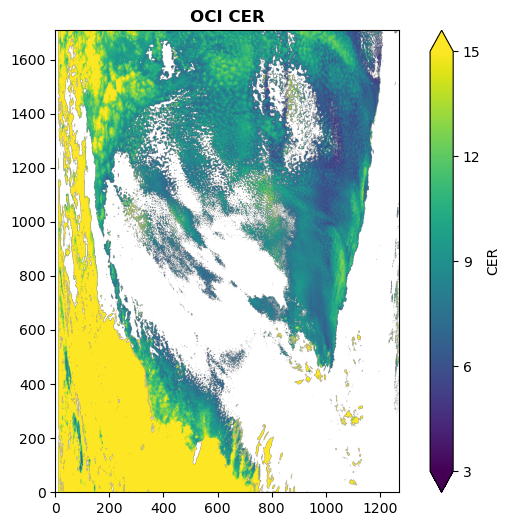

In [27]:
plt.figure(figsize=(8,6))
img = plt.imshow(OCI_CER, cmap='viridis', vmin=3, vmax=15, origin='lower')
plt.title('OCI CER', color='k', fontweight='bold')
plt.colorbar(img, extend='both', label='CER', ticks=np.arange(3, 16, 3))
plt.show()

In [12]:
y0,x0 = 26,267
y1,x1 = 289,269 

CER of pixel: 22.21 μm


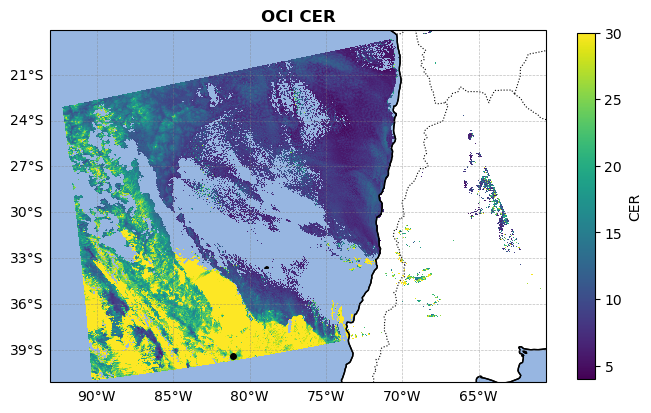

In [29]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(lon, lat, OCI_CER, vmin=4, vmax=30, cmap='viridis', shading='auto')

# ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=4, transform=ccrs.PlateCarree())
ax.plot(lon[y0, x0], lat[y0, x0], marker='o', color='k', markersize=4, transform=ccrs.PlateCarree())
print(f'CER of pixel: {OCI_CER[y0,x0]:.2f} μm')

ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('OCI CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.75, pad=0.05)
cbar.set_label('CER')

# plt.savefig("OCI.png", dpi=500, bbox_inches="tight")
plt.show()

In [15]:
# # Plotting
# plt.figure(figsize=(8, 6))
# ax = plt.axes(projection=ccrs.PlateCarree())

# img = ax.pcolormesh(lon_h, lat_h, HARP2_CER, vmin=4, vmax=30, cmap='jet', shading='auto')

# ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=4, transform=ccrs.PlateCarree())
# print(f'CER of pixel: {HARP2_CER[y0,x0]:.2f} μm')

# # ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='o', color='w', markersize=4, transform=ccrs.PlateCarree())
# # print(f'CER of pixel: {HARP2_CER[y1,x1]:.2f} μm')

# ax.coastlines()
# ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
# ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
# ax.add_feature(cfeature.OCEAN)
# ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

# gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# # gl.xlines = False
# # gl.ylines = False

# cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
# cbar.set_label('CER')

# # plt.savefig("HARP2.png", dpi=500, bbox_inches="tight")
# plt.show()

In [16]:
# HARP2_CEV = ds_HARP2['cloud_bow_droplet_effective_variance']

# plt.figure(figsize=(8, 6))
# ax = plt.axes(projection=ccrs.PlateCarree())

# img = ax.pcolormesh(lon_h, lat_h, HARP2_CEV, vmin=0, vmax=0.2, cmap='jet', shading='auto')

# ax.plot(lon_h[y0, x0], lat_h[y0, x0], marker='o', color='k', markersize=5, transform=ccrs.PlateCarree())
# print(f'CEV of pixel: {HARP2_CEV[y0,x0]:.2f}')

# # ax.plot(lon_h[y1, x1], lat_h[y1, x1], marker='o', color='w', markersize=5, transform=ccrs.PlateCarree())
# # print(f'CEV of pixel: {HARP2_CEV[y1,x1]:.2f}')

# ax.coastlines()
# ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
# ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
# ax.add_feature(cfeature.OCEAN)
# ax.set_title('HARP2 CEV', fontsize=12, color='k', fontweight='bold')

# gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# # gl.xlines = False
# # gl.ylines = False

# cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
# cbar.set_label('CEV')

# plt.show()

In [17]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# # First subplot: OCI CER 
# im1 = axes[0].pcolormesh(lon, lat, OCI_CER, vmin=4, vmax=30, cmap='jet', shading='auto')
# axes[0].coastlines()
# axes[0].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
# axes[0].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
# axes[0].add_feature(cfeature.OCEAN)
# axes[0].set_title('OCI CER', fontsize=12, fontweight='bold')

# gl = axes[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
#                        color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False

# cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', shrink=0.7, pad=0.05)
# cbar1.set_label('CER')

# # Second subplot: HARP2 CER
# im2 = axes[1].pcolormesh(lon_h, lat_h, HARP2_CER, vmin=4, vmax=30, cmap='jet', shading='auto')
# axes[1].coastlines()
# axes[1].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
# axes[1].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
# axes[1].add_feature(cfeature.OCEAN)
# axes[1].set_title('HARP2 CER', fontsize=12, fontweight='bold')

# gl = axes[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
#                        color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False

# cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', shrink=0.7, pad=0.05)
# cbar2.set_label('CER')

# plt.tight_layout()
# # plt.savefig("OCI_HARP2.png", dpi=500, bbox_inches="tight")
# plt.show()